# Double-Pendulum Forecasting Benchmark

This notebook generates the publication figures for the double-pendulum forecasting benchmark. One high-fidelity sensor and multiple low-fidelity sensors observe the same clean trajectory over 10 s. The HF observations use a 1% noise level and the LF observations use a 10% noise level, both modulated in time by the instantaneous angular-speed magnitude.

By default the identification step uses a degree-3 polynomial library, which deliberately does not contain the true double-pendulum terms. All paper assets produced by this notebook are saved under `examples/double_pendulum/results/paper_figures` and `examples/double_pendulum/results/paper_tables`.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mfsindy.cases.double_pendulum_forecasting import (
    DEFAULT_HF_NOISE_SCALE,
    DEFAULT_LF_NOISE_SCALE,
    DEFAULT_OMEGA_RANGE,
    DEFAULT_POLY_DEGREE,
    DEFAULT_THETA_RANGE,
    benchmark_double_pendulum_fidelities,
    build_double_pendulum_dataset,
    evaluate_double_pendulum_models,
    fit_double_pendulum_hf_lf_models,
    format_weighted_weak_equations,
    summarize_fidelity_benchmark,
)

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent.parent / "src").exists():
    PROJECT_ROOT = cwd.parent.parent
else:
    PROJECT_ROOT = cwd

RESULTS_DIR = PROJECT_ROOT / "examples" / "double_pendulum" / "results"
FIGURES_DIR = RESULTS_DIR / "paper_figures"
TABLES_DIR = RESULTS_DIR / "paper_tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    pdf_path = FIGURES_DIR / f"{stem}.pdf"
    png_path = FIGURES_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"saved {pdf_path.relative_to(PROJECT_ROOT)}")
    print(f"saved {png_path.relative_to(PROJECT_ROOT)}")


seed = 0
LIBRARY_KIND = "polynomial"  # switch to "true" for the physics-informed library
N_HF = 1
N_LF = 5
TRAIN_HORIZON = 10.0
DT = 0.01
FORECAST_HORIZON = 5.0
QUANTILE_BAND = (0.1, 0.9)

MODEL_ORDER = ["HF", "LF", "MF"]
MODEL_COLORS = {
    "HF": "#1f77b4",
    "LF": "#d62728",
    "MF": "#2ca02c",
}
STATE_LABELS = [r"$\theta_1$", r"$\omega_1$", r"$\theta_2$", r"$\omega_2$"]
DERIVATIVE_LABELS = [
    r"$\dot{\theta}_1$",
    r"$\dot{\omega}_1$",
    r"$\dot{\theta}_2$",
    r"$\dot{\omega}_2$",
]

dataset = build_double_pendulum_dataset(
    n_hf=N_HF,
    n_lf=N_LF,
    t_final=TRAIN_HORIZON,
    dt=DT,
    hf_noise_scale=DEFAULT_HF_NOISE_SCALE,
    lf_noise_scale=DEFAULT_LF_NOISE_SCALE,
    seed=seed,
    theta_range=DEFAULT_THETA_RANGE,
    omega_range=DEFAULT_OMEGA_RANGE,
)

t = dataset.t
hf_clean = dataset.hf.clean[0]
hf_noisy = dataset.hf.noisy[0]
lf_noisy = dataset.lf.noisy
hf_sigma = np.sqrt(np.mean(dataset.hf.variance[0], axis=1))
lf_sigma = np.sqrt(np.mean(dataset.lf.variance[0], axis=1))

theta1, omega1, theta2, omega2 = hf_clean.T
hf_theta1, hf_omega1, hf_theta2, hf_omega2 = hf_noisy.T

{
    "seed": seed,
    "library_kind": LIBRARY_KIND,
    "n_hf": N_HF,
    "n_lf": N_LF,
    "theta_range": DEFAULT_THETA_RANGE,
    "omega_range": DEFAULT_OMEGA_RANGE,
    "hf_noise_scale": DEFAULT_HF_NOISE_SCALE,
    "lf_noise_scale": DEFAULT_LF_NOISE_SCALE,
    "results_dir": str(RESULTS_DIR.relative_to(PROJECT_ROOT)),
}


{'seed': 0,
 'library_kind': 'polynomial',
 'n_hf': 1,
 'n_lf': 5,
 'theta_range': (-1.0471975511965976, 1.0471975511965976),
 'omega_range': (-0.0, 0.0),
 'hf_noise_scale': 0.01,
 'lf_noise_scale': 0.1,
 'results_dir': 'examples/double_pendulum/results'}

saved examples/double_pendulum/results/paper_figures/double_pendulum_schematic_tail.pdf
saved examples/double_pendulum/results/paper_figures/double_pendulum_schematic_tail.png


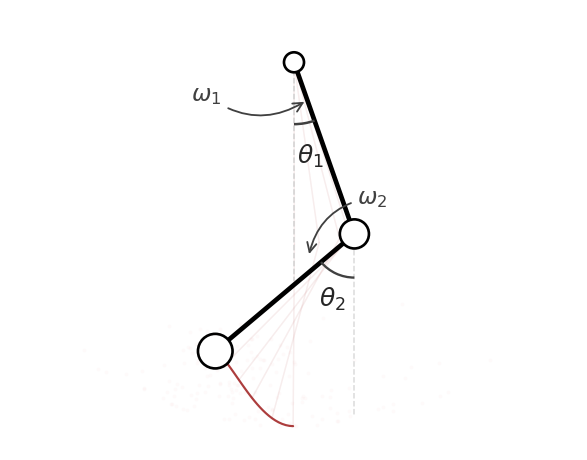

In [2]:
from matplotlib.patches import Arc, Circle
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Assumed already available in your workspace:
# t
# theta1, theta2, omega1, omega2
# lf_noisy
# MODEL_COLORS["LF"]
# cartesian_positions(theta1, theta2, l1=1.0, l2=1.0)
# save_figure(fig, name)
# ------------------------------------------------------------
def cartesian_positions(theta1, theta2, l1=1.0, l2=1.0):
    x1 = l1 * np.sin(theta1)
    y1 = -l1 * np.cos(theta1)
    x2 = x1 + l2 * np.sin(theta2)
    y2 = y1 - l2 * np.cos(theta2)
    return x1, y1, x2, y2

def draw_angle_arc(ax, center, radius, theta1_deg, theta2_deg, lw=1.4, color="0.25", zorder=6):
    arc = Arc(
        center,
        2 * radius,
        2 * radius,
        angle=0,
        theta1=min(theta1_deg, theta2_deg),
        theta2=max(theta1_deg, theta2_deg),
        lw=lw,
        color=color,
        zorder=zorder,
    )
    ax.add_patch(arc)


def add_curved_arrow(ax, xy, xytext, text, rad=0.35, color="0.25", fontsize=13):
    ax.annotate(
        text,
        xy=xy,
        xytext=xytext,
        fontsize=fontsize,
        color=color,
        ha="center",
        va="center",
        arrowprops=dict(
            arrowstyle="->",
            lw=1.1,
            color=color,
            shrinkA=2,
            shrinkB=2,
            connectionstyle=f"arc3,rad={rad}",
        ),
        zorder=8,
    )


# ============================================================
# FIGURE 1 — Refined schematic + last-instants clean trajectory
# ============================================================

# style knobs
TAIL_COLOR = "#9e1b1b"
TAIL_LW = 1.3
SCHEMATIC_TRAIL_ALPHA = 0.85
GHOST_ALPHA = 0.08

l1, l2 = 1.0, 1.0

# clean Cartesian trajectories
x1, y1, x2, y2 = cartesian_positions(theta1, theta2, l1=l1, l2=l2)

# final configuration
th1_f = theta1[-1]
th2_f = theta2[-1]
x1_f, y1_f, x2_f, y2_f = cartesian_positions(
    np.array([th1_f]), np.array([th2_f]), l1=l1, l2=l2
)
x1_f, y1_f, x2_f, y2_f = x1_f.item(), y1_f.item(), x2_f.item(), y2_f.item()

# rod angles in degrees with respect to standard plotting convention
phi1 = np.degrees(th1_f) - 90.0
phi2 = np.degrees(th2_f) - 90.0

# tail near final time
tail_window = 35
i_tail = max(0, len(t) - tail_window)

# LF subset only for faint background context
max_lf_tail = min(len(lf_noisy), 20)
lf_subset_tail = lf_noisy[:max_lf_tail]

fig1, ax = plt.subplots(figsize=(5.0, 5.0))

# ------------------------------------------------------------
# Clean end-mass tail
# ------------------------------------------------------------
ax.plot(
    x2[i_tail:],
    y2[i_tail:],
    color=TAIL_COLOR,
    lw=TAIL_LW,
    alpha=SCHEMATIC_TRAIL_ALPHA,
    zorder=1,
)

# Ghosted recent configurations
ghost_idx = np.linspace(i_tail, len(t) - 2, 6, dtype=int)
for k in ghost_idx:
    gx1, gy1, gx2, gy2 = x1[k], y1[k], x2[k], y2[k]
    ax.plot([0, gx1], [0, gy1], color=TAIL_COLOR, lw=0.9, alpha=GHOST_ALPHA, zorder=1)
    ax.plot([gx1, gx2], [gy1, gy2], color=TAIL_COLOR, lw=0.9, alpha=GHOST_ALPHA, zorder=1)

# Optional LF tail cloud in the background
for lf_traj in lf_subset_tail:
    _, _, lf_x2, lf_y2 = cartesian_positions(lf_traj[:, 0], lf_traj[:, 2], l1=l1, l2=l2)
    ax.scatter(
        lf_x2[i_tail:],
        lf_y2[i_tail:],
        s=5,
        color=MODEL_COLORS["LF"],
        alpha=0.018,
        linewidths=0,
        rasterized=True,
        zorder=0,
    )

# ------------------------------------------------------------
# Reference verticals
# ------------------------------------------------------------
ax.plot([0, 0], [0, -1.2], ls="--", lw=0.9, color="0.82", zorder=2)
ax.plot([x1_f, x1_f], [y1_f, y1_f - 1.0], ls="--", lw=0.9, color="0.86", zorder=2)

# ------------------------------------------------------------
# Main pendulum rods
# ------------------------------------------------------------
ax.plot([0, x1_f], [0, y1_f], color="black", lw=2.8, solid_capstyle="round", zorder=4)
ax.plot([x1_f, x2_f], [y1_f, y2_f], color="black", lw=2.8, solid_capstyle="round", zorder=4)

# ------------------------------------------------------------
# Pivot and masses
# ------------------------------------------------------------
pivot = Circle((0, 0), 0.055, facecolor="white", edgecolor="black", lw=1.6, zorder=7)
mass1 = Circle((x1_f, y1_f), 0.080, facecolor="white", edgecolor="black", lw=1.6, zorder=7)
mass2 = Circle((x2_f, y2_f), 0.095, facecolor="white", edgecolor="black", lw=1.6, zorder=7)

ax.add_patch(pivot)
ax.add_patch(mass1)
ax.add_patch(mass2)

# ------------------------------------------------------------
# Angle arcs
# ------------------------------------------------------------
draw_angle_arc(ax, (0, 0), radius=0.34, theta1_deg=-90, theta2_deg=phi1, lw=1.5)
draw_angle_arc(ax, (x1_f, y1_f), radius=0.24, theta1_deg=-90, theta2_deg=phi2, lw=1.4)

# ------------------------------------------------------------
# Angle labels
# ------------------------------------------------------------
mid1 = np.radians((-90 + phi1) / 2)
ax.text(
    0.52 * np.cos(mid1),
    0.52 * np.sin(mid1),
    r"$\theta_1$",
    fontsize=15,
    ha="center",
    va="center",
    zorder=8,
)

mid2 = np.radians((-90 + phi2) / 2)
ax.text(
    x1_f + 0.36 * np.cos(mid2) + 0.03,
    y1_f + 0.36 * np.sin(mid2) - 0.03,
    r"$\theta_2$",
    fontsize=15,
    ha="center",
    va="center",
    zorder=8,
)

# ------------------------------------------------------------
# Angular velocity annotations
# ------------------------------------------------------------
u1 = np.array([x1_f, y1_f], dtype=float)
u1 = u1 / np.linalg.norm(u1)
p1 = np.array([0.22 * u1[0], 0.22 * u1[1]])
omega1_text = np.array([-0.48, -0.18])

add_curved_arrow(
    ax,
    xy=p1,
    xytext=omega1_text,
    text=r"$\omega_1$",
    rad=-0.35 if omega1[-1] >= 0 else 0.35,
    fontsize=14,
)

u2 = np.array([x2_f - x1_f, y2_f - y1_f], dtype=float)
u2 = u2 / np.linalg.norm(u2)
p2 = np.array([x1_f-0.1, y1_f]) + 0.20 * u2
omega2_text = np.array([x1_f + 0.1, y1_f + 0.2])

add_curved_arrow(
    ax,
    xy=p2,
    xytext=omega2_text,
    text=r"$\omega_2$",
    rad=-0.35 if omega2[-1] >= 0 else 0.35,
    fontsize=14,
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.55, 1.55)
ax.set_ylim(-2.12, 0.28)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig1, "double_pendulum_schematic_tail")
plt.show()


saved examples/double_pendulum/results/paper_figures/double_pendulum_theta1_theta2.pdf
saved examples/double_pendulum/results/paper_figures/double_pendulum_theta1_theta2.png


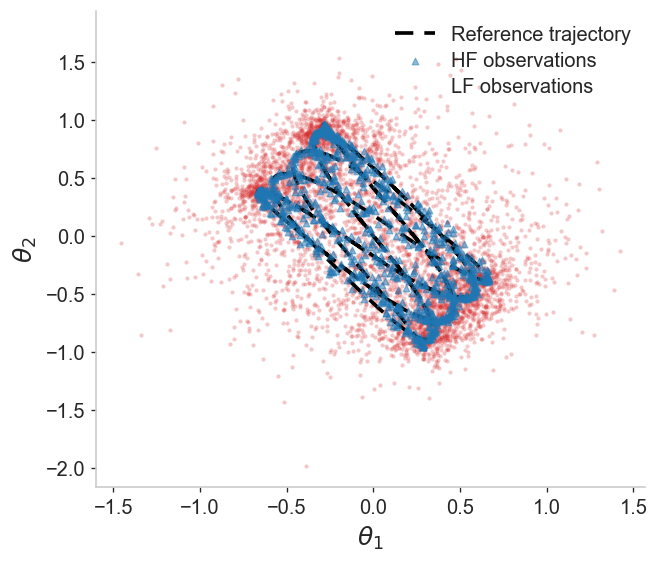

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import Arc, Circle


# # ============================================================
# # Helpers
# # ============================================================


def style_axis(ax, xlabel=None, ylabel=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=15)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=12, length=3)

# # ------------------------------------------------------------
# # Common style knobs
# # ------------------------------------------------------------
LF_ALPHA = 0.25
LF_SIZE = 25

HF_ALPHA = 0.5
HF_SIZE = 16

REF_COLOR = "black"
REF_LW = 2.2
REF_LS = (0, (5, 3))

TAIL_COLOR = "#8c1515"   # dark red for last-instants tail
TAIL_LW = 1.6

# ============================================================
# FIGURE 2 — Configuration-space plot: (theta1, theta2)
# using all trajectories
# ============================================================
fig2, ax = plt.subplots(figsize=(5.6, 4.8))

# LF trajectories
for idx, lf_traj in enumerate(lf_noisy):
    ax.scatter(
        lf_traj[:, 0],
        lf_traj[:, 2],
        s=LF_SIZE,
        color=MODEL_COLORS["LF"],
        marker=".",
        alpha=LF_ALPHA,
        linewidths=0,
        rasterized=True,
        label="LF observations" if idx == 0 else None,
        zorder=1,
    )

# HF observations
ax.scatter(
    hf_theta1,
    hf_theta2,
    s=HF_SIZE,
    color=MODEL_COLORS["HF"],
    marker="^",
    alpha=HF_ALPHA,
    linewidths=0.7,
    label="HF observations",
    zorder=4,
)

# Reference full trajectory
ax.plot(
    theta1,
    theta2,
    color=REF_COLOR,
    lw=REF_LW,
    ls=REF_LS,
    label="Reference trajectory",
    zorder=3,
)

style_axis(ax, xlabel=r"$\theta_1$", ylabel=r"$\theta_2$")

handles, labels = ax.get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))
legend_order = ["Reference trajectory", "HF observations", "LF observations"]
ax.legend(
    [label_to_handle[l] for l in legend_order if l in label_to_handle],
    [l for l in legend_order if l in label_to_handle],
    loc="upper right",
    frameon=False,
    fontsize=12,
    handlelength=2.0,
    borderpad=0.2,
    labelspacing=0.35,
)

plt.tight_layout()
save_figure(fig2, "double_pendulum_theta1_theta2")
plt.show()


saved examples/double_pendulum/results/paper_figures/double_pendulum_observations.pdf
saved examples/double_pendulum/results/paper_figures/double_pendulum_observations.png


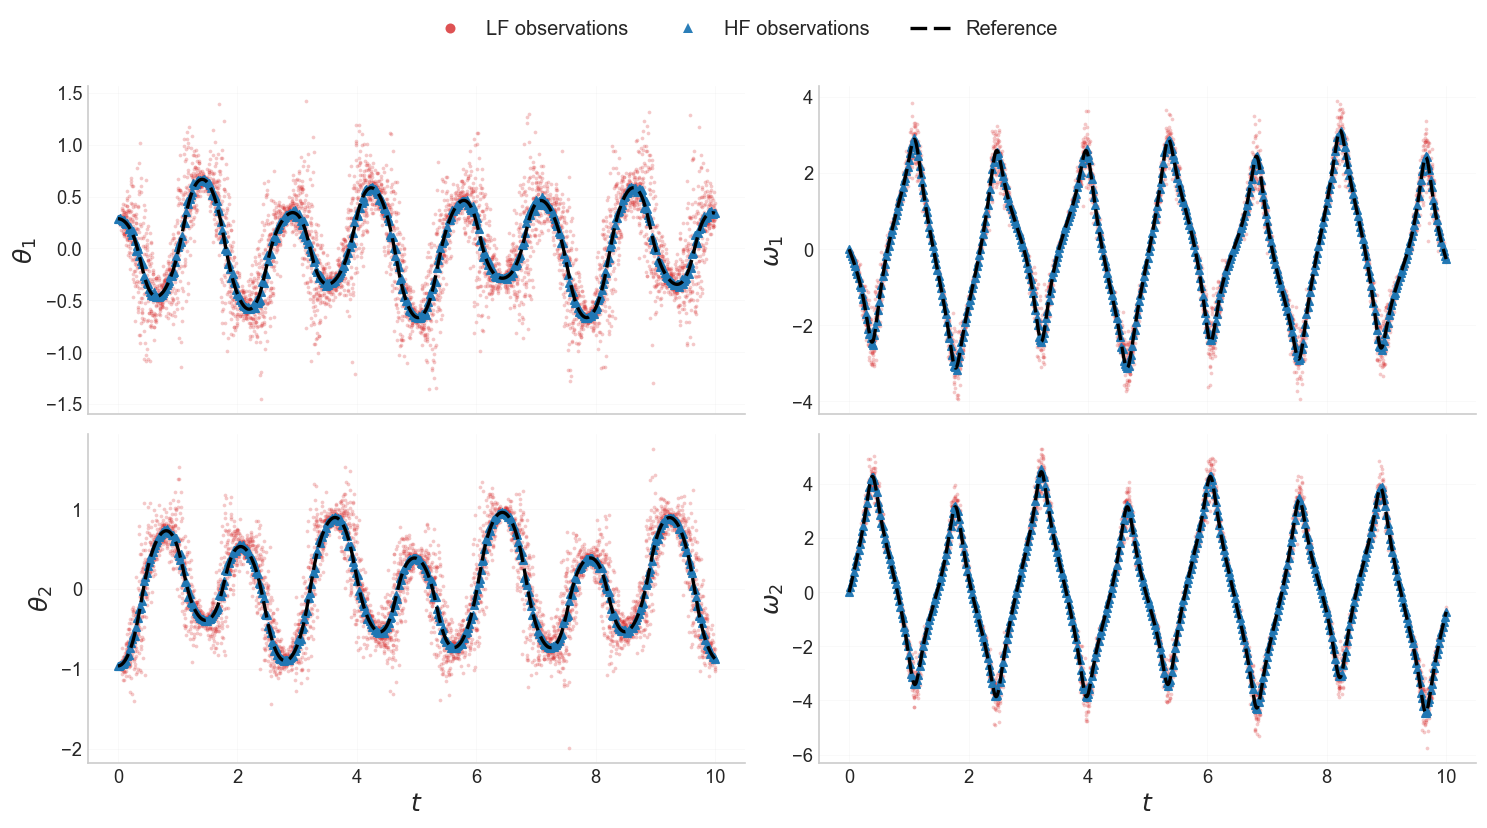

In [4]:
from matplotlib.lines import Line2D

state_labels = [r"$\theta_1$", r"$\omega_1$", r"$\theta_2$", r"$\omega_2$"]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.8), sharex=True)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    # LF observations
    for lf_traj in lf_noisy:
        ax.scatter(
            t,
            lf_traj[:, idx],
            s=20,
            color=MODEL_COLORS["LF"],
            alpha=0.25,
            linewidths=0,
            rasterized=True,
            zorder=1,
            marker='.'
        )

    # HF observations
    ax.scatter(
        t[::2],
        hf_noisy[::2, idx],
        s=20,
        color=MODEL_COLORS["HF"],
        alpha=0.95,
        marker="^",
        zorder=3,
    )

    # Clean reference on top
    ax.plot(
        t,
        hf_clean[:, idx],
        color="black",
        lw=2.0,
        ls=(0, (5, 2)),
        zorder=4,
    )

    ax.set_ylabel(state_labels[idx], fontsize=15)
    ax.grid(True, alpha=0.10, linewidth=0.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)

axes[2].set_xlabel(r"$t$", fontsize=15)
axes[3].set_xlabel(r"$t$", fontsize=15)

# Custom legend handles so markers are visible
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=6,
        markerfacecolor=MODEL_COLORS["LF"],
        markeredgewidth=0,
        alpha=0.8,
        label="LF observations",
    ),
    Line2D(
        [0], [0],
        marker="^",
        linestyle="None",
        markersize=6,
        markerfacecolor=MODEL_COLORS["HF"],
        markeredgewidth=0,
        alpha=0.95,
        label="HF observations",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=2.0,
        ls=(0, (5, 2)),
        label="Reference",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=12,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
save_figure(fig, "double_pendulum_observations")
plt.show()


## Weighted Weak-SINDy Fit

We fit the three models used in the forecasting comparison:
- `HF`: one high-fidelity sensor only,
- `LF`: the low-fidelity sensor ensemble only,
- `MF`: the combined HF/LF dataset with the trajectory-wise variance profiles used directly in the weak regression.

The same sparse-regression settings are used for all three models.

In [5]:
STLSQ_THRESHOLD = 0.5
STLSQ_ALPHA = 1e-12
N_ENSEMBLE_MODELS = 25
N_WEAK_CELLS = 200
WEAK_WINDOW_LENGTH = 0.05

fit_results = fit_double_pendulum_hf_lf_models(
    dataset,
    library_kind=LIBRARY_KIND,
    poly_degree=DEFAULT_POLY_DEGREE,
    stlsq_threshold=STLSQ_THRESHOLD,
    stlsq_alpha=STLSQ_ALPHA,
    n_ensemble_models=N_ENSEMBLE_MODELS,
    weak_seed=seed,
    n_weak_cells=N_WEAK_CELLS,
    weak_window_length=WEAK_WINDOW_LENGTH,
)

for model_name in MODEL_ORDER:
    result = fit_results[model_name]
    print(f"{model_name} weighted weak-SINDy model")
    print(f"retained features: {np.count_nonzero(np.abs(result.coefficients) > 1e-12)}")
    for equation in format_weighted_weak_equations(result.coefficients, result.feature_names):
        print(equation)
    print()


/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


HF weighted weak-SINDy model
retained features: 28
theta1_dot = 1.014 omega1 + 1.194 theta1^3 + 2.620 theta1^2 theta2 + 0.789 theta1 theta2^2
omega1_dot = -8.531 theta2 - 1.944 theta1^3 + 62.447 theta1^2 theta2 + 3.783 theta1 omega1 omega2 + 22.102 theta1 theta2^2 + 4.173 omega1^2 theta2 + 3.354 omega1 theta2 omega2 + 13.656 theta2^3 + 2.425 theta2 omega2^2
theta2_dot = -1.196 omega1 + 0.726 theta1^2 omega1 + 1.014 theta1^2 omega2 - 1.804 theta1 omega1 theta2 - 1.060 theta1 theta2 omega2
omega2_dot = 5.638 theta2 + 5.720 theta1^3 - 47.094 theta1^2 theta2 + 2.124 theta1 omega1^2 - 1.702 theta1 omega1 omega2 + 0.875 theta1 omega2^2 - 4.355 omega1^2 theta2 - 1.320 omega1 theta2 omega2 - 13.723 theta2^3 - 2.114 theta2 omega2^2

LF weighted weak-SINDy model
retained features: 37
theta1_dot = 1.625 theta1 + 1.170 omega1 - 3.544 theta1^3 - 2.655 theta1^2 theta2 + 1.945 theta1^2 omega2
omega1_dot = -14.372 theta1 + 5.391 theta2 + 1.294 theta1^3 + 0.962 theta1^2 omega1 - 7.066 theta1^2 theta2 +

In [6]:
evaluation = evaluate_double_pendulum_models(
    dataset,
    fit_results,
    forecast_horizon=FORECAST_HORIZON,
    forecast_dt=DT,
    quantile_band=QUANTILE_BAND,
    library_kind=LIBRARY_KIND,
    poly_degree=DEFAULT_POLY_DEGREE,
)

t_future = evaluation.t_future
true_future = evaluation.true_future
true_future_derivatives = evaluation.true_future_derivatives
t_future_abs = t[-1] + t_future
forecast_summaries = evaluation.forecast_summaries
derivative_summaries = evaluation.derivative_summaries


saved examples/double_pendulum/results/paper_figures/double_pendulum_forecast_polynomial.pdf
saved examples/double_pendulum/results/paper_figures/double_pendulum_forecast_polynomial.png


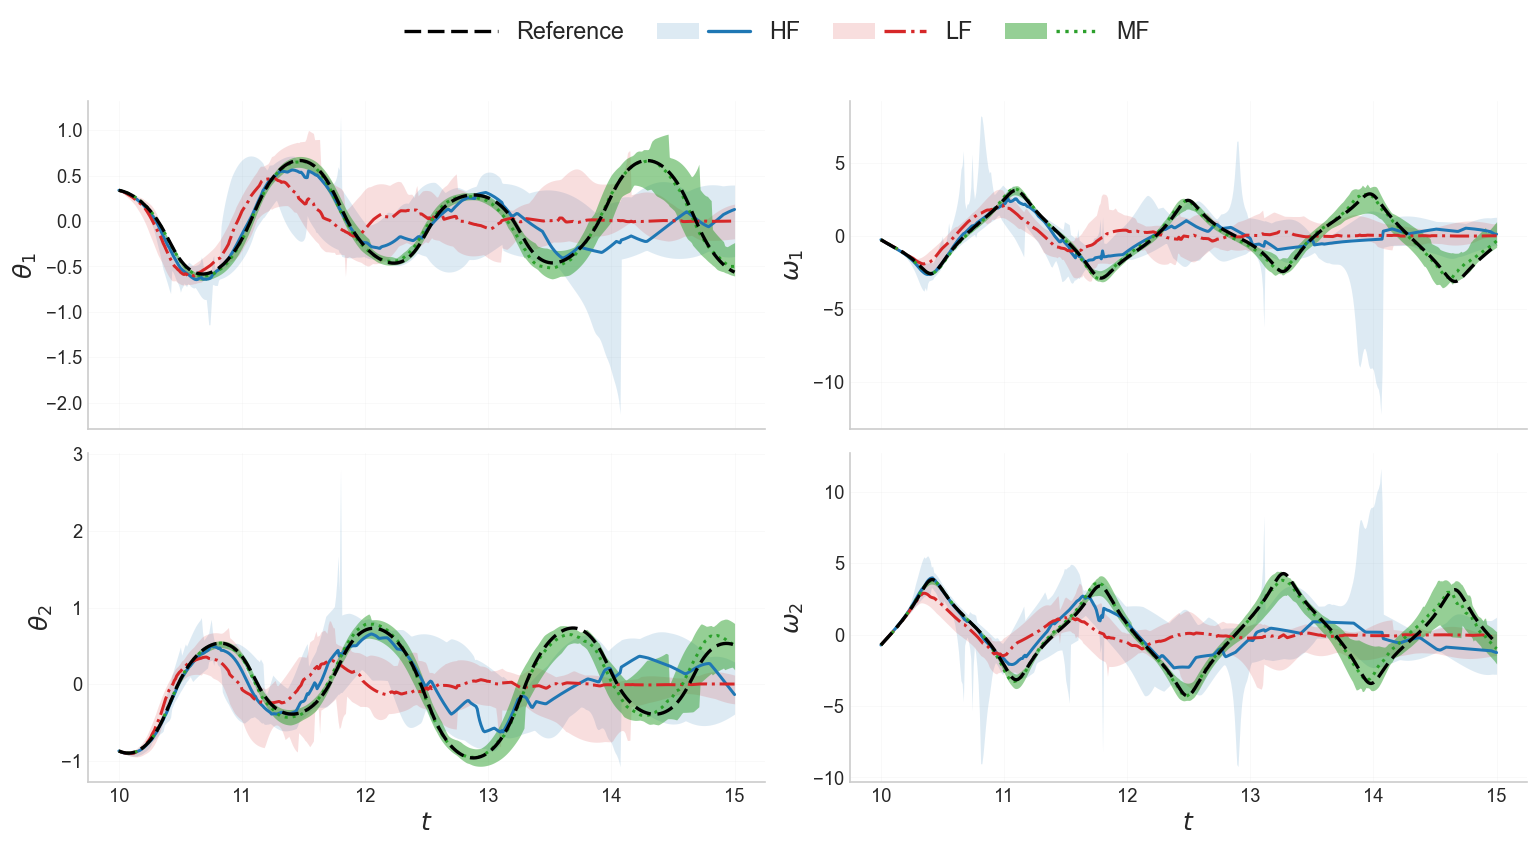

In [7]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
import pandas as pd

state_labels = [r"$\theta_1$", r"$\omega_1$", r"$\theta_2$", r"$\omega_2$"]

alphas = [0.15, 0.15, 0.5]

MODEL_LINESTYLES = {
    MODEL_ORDER[0]: "-",
    MODEL_ORDER[1]: "-.",
    MODEL_ORDER[2]: ":",
}

fig, axes = plt.subplots(2, 2, figsize=(12.8, 6.9), sharex=True)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    for iidx, model_name in enumerate(MODEL_ORDER):
        summary = forecast_summaries[model_name]

        ax.fill_between(
            t_future_abs,
            summary.lower[:, idx],
            summary.upper[:, idx],
            color=MODEL_COLORS[model_name],
            alpha=alphas[iidx],
            linewidth=0.0,
            zorder=1,
        )

        ax.plot(
            t_future_abs,
            summary.median[:, idx],
            color=MODEL_COLORS[model_name],
            lw=1.8,
            ls=MODEL_LINESTYLES[model_name],
            zorder=2,
        )

    ax.plot(
        t_future_abs,
        true_future[:, idx],
        color="black",
        lw=2.0,
        ls=(0, (5, 2)),
        zorder=4,
    )

    ax.set_ylabel(state_labels[idx], fontsize=15)
    ax.grid(True, alpha=0.10, linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)

axes[2].set_xlabel(r"$t$", fontsize=15)
axes[3].set_xlabel(r"$t$", fontsize=15)

legend_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.0,
        ls=(0, (5, 2)),
        label="Reference",
    )
]

legend_labels = ["Reference"]

for iidx, model_name in enumerate(MODEL_ORDER):
    band = Patch(
        facecolor=MODEL_COLORS[model_name],
        edgecolor="none",
        alpha=alphas[iidx],
    )
    line = Line2D(
        [0], [0],
        color=MODEL_COLORS[model_name],
        lw=2.0,
        ls=MODEL_LINESTYLES[model_name],
    )
    legend_handles.append((band, line))
    legend_labels.append(model_name)

fig.legend(
    legend_handles,
    legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="upper center",
    ncol=min(len(legend_labels), 4),
    frameon=False,
    bbox_to_anchor=(0.5, 1.03),
    fontsize=14,
    columnspacing=1.4,
    handlelength=4,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
save_figure(fig, f"double_pendulum_forecast_{LIBRARY_KIND}")
plt.show()


/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  w

saved examples/double_pendulum/results/paper_tables/double_pendulum_seed_rows_polynomial.csv
saved examples/double_pendulum/results/paper_tables/double_pendulum_seed_summary_polynomial.csv
saved examples/double_pendulum/results/paper_figures/double_pendulum_benchmark_summary_polynomial.pdf
saved examples/double_pendulum/results/paper_figures/double_pendulum_benchmark_summary_polynomial.png


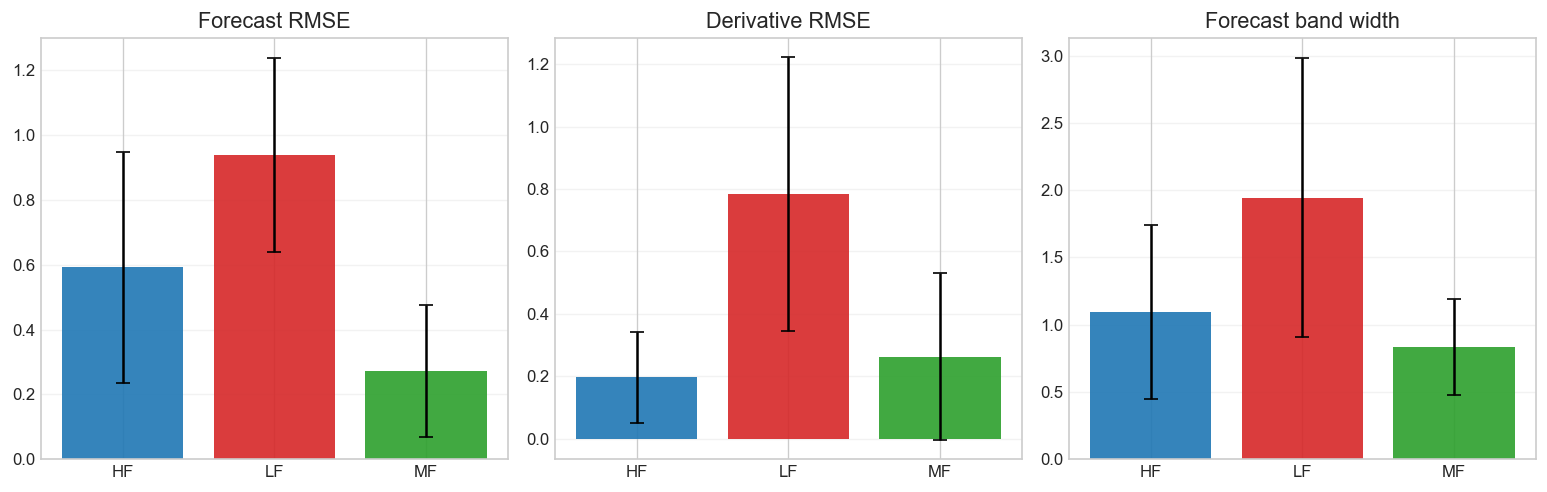

,model,n_seeds,forecast_rmse_mean,forecast_rmse_std,forecast_width_mean,forecast_coverage_mean,derivative_rmse_mean,derivative_width_mean,derivative_coverage_mean
0,HF,25,0.5922,0.3562,1.0930,0.6927,0.1971,0.3703,0.7721
1,LF,25,0.9395,0.2987,1.9439,0.6305,0.7832,1.3538,0.7088
2,MF,25,0.2722,0.2052,0.8321,0.8580,0.2631,0.2716,0.6819


In [8]:
benchmark_seeds = list(range(25))  # increase this for final manuscript statistics

benchmark_rows = benchmark_double_pendulum_fidelities(
    benchmark_seeds,
    n_hf=N_HF,
    n_lf=N_LF,
    t_final=TRAIN_HORIZON,
    dt=DT,
    hf_noise_scale=DEFAULT_HF_NOISE_SCALE,
    lf_noise_scale=DEFAULT_LF_NOISE_SCALE,
    theta_range=DEFAULT_THETA_RANGE,
    omega_range=DEFAULT_OMEGA_RANGE,
    library_kind=LIBRARY_KIND,
    poly_degree=DEFAULT_POLY_DEGREE,
    stlsq_threshold=STLSQ_THRESHOLD,
    stlsq_alpha=STLSQ_ALPHA,
    n_ensemble_models=N_ENSEMBLE_MODELS,
    n_weak_cells=N_WEAK_CELLS,
    weak_window_length=WEAK_WINDOW_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    forecast_dt=DT,
)

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_summary = (
    pd.DataFrame(summarize_fidelity_benchmark(benchmark_rows))
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

benchmark_rows_path = TABLES_DIR / f"double_pendulum_seed_rows_{LIBRARY_KIND}.csv"
benchmark_summary_path = TABLES_DIR / f"double_pendulum_seed_summary_{LIBRARY_KIND}.csv"
benchmark_df.to_csv(benchmark_rows_path, index=False)
benchmark_summary.to_csv(benchmark_summary_path, index=False)
print(f"saved {benchmark_rows_path.relative_to(PROJECT_ROOT)}")
print(f"saved {benchmark_summary_path.relative_to(PROJECT_ROOT)}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
metric_specs = [
    ("forecast_rmse_mean", "forecast_rmse_std", "Forecast RMSE"),
    ("derivative_rmse_mean", "derivative_rmse_std", "Derivative RMSE"),
    ("forecast_width_mean", "forecast_width_std", "Forecast band width"),
]

for ax, (mean_key, std_key, title) in zip(axes, metric_specs, strict=True):
    ax.bar(
        benchmark_summary["model"],
        benchmark_summary[mean_key],
        yerr=benchmark_summary[std_key],
        color=[MODEL_COLORS[name] for name in benchmark_summary["model"]],
        alpha=0.9,
        capsize=4,
    )
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
save_figure(fig, f"double_pendulum_benchmark_summary_{LIBRARY_KIND}")
plt.show()

benchmark_summary[
    [
        "model",
        "n_seeds",
        "forecast_rmse_mean",
        "forecast_rmse_std",
        "forecast_width_mean",
        "forecast_coverage_mean",
        "derivative_rmse_mean",
        "derivative_width_mean",
        "derivative_coverage_mean",
    ]
].round(4)


In [9]:
benchmark_summary[
    [
        "model",
        "n_seeds",
        "forecast_rmse_mean",
        "forecast_rmse_std",
        "forecast_width_mean",
        "forecast_width_std",
        "forecast_coverage_mean",
        "forecast_coverage_std",
        "derivative_rmse_mean",
        "derivative_rmse_std",
        "derivative_width_mean",
        "derivative_width_std",
        "derivative_coverage_mean",
        "derivative_coverage_std",
    ]
].round(4)


,model,n_seeds,forecast_rmse_mean,forecast_rmse_std,forecast_width_mean,forecast_width_std,forecast_coverage_mean,forecast_coverage_std,derivative_rmse_mean,derivative_rmse_std,derivative_width_mean,derivative_width_std,derivative_coverage_mean,derivative_coverage_std
0,HF,25,0.5922,0.3562,1.0930,0.6460,0.6927,0.2460,0.1971,0.1458,0.3703,0.1735,0.7721,0.0740
1,LF,25,0.9395,0.2987,1.9439,1.0382,0.6305,0.1629,0.7832,0.4395,1.3538,0.4471,0.7088,0.0737
2,MF,25,0.2722,0.2052,0.8321,0.3552,0.8580,0.0994,0.2631,0.2677,0.2716,0.1509,0.6819,0.0894
